# <span style="color:#0095b6"> Decision Tree  only 3 features </span>

This notebook analyses and evaluates the Nepal Earthquake Dataset using Decision trees algorithm considering only Geo IDs

-  Basic visual exploration > correlation: Target < Damage grade > vs Total < counts>. the outcome shows imbalanced dataset

- The Dataset is reduced to consider only Geo Ids

-  Hyperparameter tuning on Grid search is perfomed for best parameters

-  Decision tree is used as algorithm to classify

-  The model is evaluated Confusion matrix and F1score micro for unbalanced dataset 

- Predict with PCA and rotation to see if F1 improve >. no improvement



#### <span style="color:#0095b6"> Load Packages </span>

In [296]:
#data structures
import pandas as pd
import numpy as np
np.random.seed(42)

#figures
import seaborn as sns
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

#Plot Settings
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

#machine learning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier   # Working classifier Felipe
from sklearn.compose import ColumnTransformer


#metrics (performace and machine learning scores)
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

import time #used for seeing how long it takes to run programs

In [297]:
import os
print(os.getcwd())

/Users/Hayabusa/Dropbox/Felipe Data Science/3253_Intro to Machine Learning 3253-092/3253_M012_Final Assignment and Presentations/data


---

####  <span style="color:#0095b6">From HOML for figures </span>
- Create the images/decision_trees folder (if it doesn't already exist), and define the save_fig() function which is used through this notebook to save the figures in high-res for the book:

In [300]:
from pathlib import Path

IMAGES_PATH = Path() / "imgs" / "decision_trees_EarthQ"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=450):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

---

#### <span style="color:#0095b6"> Read Data </span>
- Main Data Frames to work with

In [303]:
train_val = pd.read_csv('train_values.csv') #The data values of each building
train_labels = pd.read_csv('train_labels.csv') #labels of data as damage severity ('damage_grade')
test_val = pd.read_csv('test_values.csv') #data values of contest submition 

# combined features target label & Features for data sampling and other transformations
df_train = pd.merge(train_val, train_labels, on='building_id')

##### <span style="color:#0095b6">  Check Data df_train + Explanation of columns: </span>

In [305]:
df_train.head(5)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


In [306]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

0) building_id  

1) geo_level_1_id (type: int): level 1: 0-30, 

2) geo_level_2_id (type: int): level 2: 0-1427

3) geo_level_3_id (type: int): level 3: 0-12567

    Descript >>  Geographic region in which building exists, from largest (level 1) to most specific sub-region (level 3). Possible values: level 1: 0-30, level 2: 0-1427, level 3: 0-12567.

4) count_floors_pre_eq (type: int): number of floors in the building before the earthquake.

5) age (type: int): age of the building in years.

6) area_percentage (type: int): normalized area of the building footprint.

7) height_percentage (type: int): normalized height of the building footprint.

8) land_surface_condition (type: categorical): surface condition of the land where the building was built. Possible values: n, o, t.

9) foundation_type (type: categorical): type of foundation used while building. Possible values: h, i, r, u, w.

10) roof_type (type: categorical): type of roof used while building. Possible values: n, q, x.

11) ground_floor_type (type: categorical): type of the ground floor. Possible values: f, m, v, x, z.

12) other_floor_type (type: categorical): type of constructions used in higher than the ground floors (except of roof). Possible values: j, q, s, x.

13) position (type: categorical): position of the building. Possible values: j, o, s, t.

14) plan_configuration (type: categorical): building plan configuration. Possible values: a, c, d, f, m, n, o, q, s, u.

15) has_superstructure_adobe_mud (type: binary): flag variable that indicates if the superstructure was made of Adobe/Mud.

16) has_superstructure_mud_mortar_stone (type: binary): flag variable that indicates if the superstructure was made of Mud Mortar - Stone.

17) has_superstructure_stone_flag (type: binary): flag variable that indicates if the superstructure was made of Stone.

18) has_superstructure_cement_mortar_stone (type: binary): flag variable that indicates if the superstructure was made of Cement Mortar - Stone.

19) has_superstructure_mud_mortar_brick (type: binary): flag variable that indicates if the superstructure was made of Mud Mortar - Brick.

20) has_superstructure_cement_mortar_brick (type: binary): flag variable that indicates if the superstructure was made of Cement Mortar - Brick.

21) has_superstructure_timber (type: binary): flag variable that indicates if the superstructure was made of Timber.

22) has_superstructure_bamboo (type: binary): flag variable that indicates if the superstructure was made of Bamboo.

23) has_superstructure_rc_non_engineered (type: binary): flag variable that indicates if the superstructure was made of non-engineered reinforced concrete.

24) has_superstructure_rc_engineered (type: binary): flag variable that indicates if the superstructure was made of engineered reinforced concrete.

25) has_superstructure_other (type: binary): flag variable that indicates if the superstructure was made of any other material.

26) legal_ownership_status (type: categorical): legal ownership status of the land where building was built. Possible values: a, r, v, w.

27) count_families (type: int): number of families that live in the building.

28) has_secondary_use (type: binary): flag variable that indicates if the building was used for any secondary purpose.

29) has_secondary_use_agriculture (type: binary): flag variable that indicates if the building was used for agricultural purposes.

30) has_secondary_use_hotel (type: binary): flag variable that indicates if the building was used as a hotel.

31) has_secondary_use_rental (type: binary): flag variable that indicates if the building was used for rental purposes.

32) has_secondary_use_institution (type: binary): flag variable that indicates if the building was used as a location of any institution.

33) has_secondary_use_school (type: binary): flag variable that indicates if the building was used as a school.

34) has_secondary_use_industry (type: binary): flag variable that indicates if the building was used for industrial purposes.

35) has_secondary_use_health_post (type: binary): flag variable that indicates if the building was used as a health post.

36) has_secondary_use_gov_office (type: binary): flag variable that indicates if the building was used fas a government office.

37) has_secondary_use_use_police (type: binary): flag variable that indicates if the building was used as a police station.

38) has_secondary_use_other (type: binary): flag variable that indicates if the building was secondarily used for other purpose

39) damage_grade 
 

Definition of geo_level_2_id

geo_level_2_id is a numeric identifier that represents a specific geographic region within a hierarchical structure. This identifier is used to categorize locations, allowing for a more organized understanding of areas from larger regions down to more specific sub-regions.
Importance in Earthquake Damage Modeling

In the context of earthquake damage modeling, particularly for events like the 2015 Gorkha earthquake in Nepal, geo_level_2_id plays a crucial role in:

    Identifying Locations: It helps pinpoint where buildings are located that were affected by the earthquake.
    Data Analysis: By categorizing buildings based on their geographic identifiers, analysts can better understand patterns of damage and the factors contributing to it.

Hierarchical Structure

The geographic hierarchy typically includes:

    Level 1: Represents the largest geographic areas (e.g., regions or provinces).
    Level 2: Represents more specific areas within those larger regions.
    Level 3: Represents the most specific sub-regions.

This structured approach allows for detailed analysis and targeted interventions in disaster response and recovery efforts.

####  <span style="color:#0095b6"> Damage Grade Count + Mini visual Plot  </span>

In [310]:
df_train['damage_grade'].value_counts()

damage_grade
2    148259
3     87218
1     25124
Name: count, dtype: int64

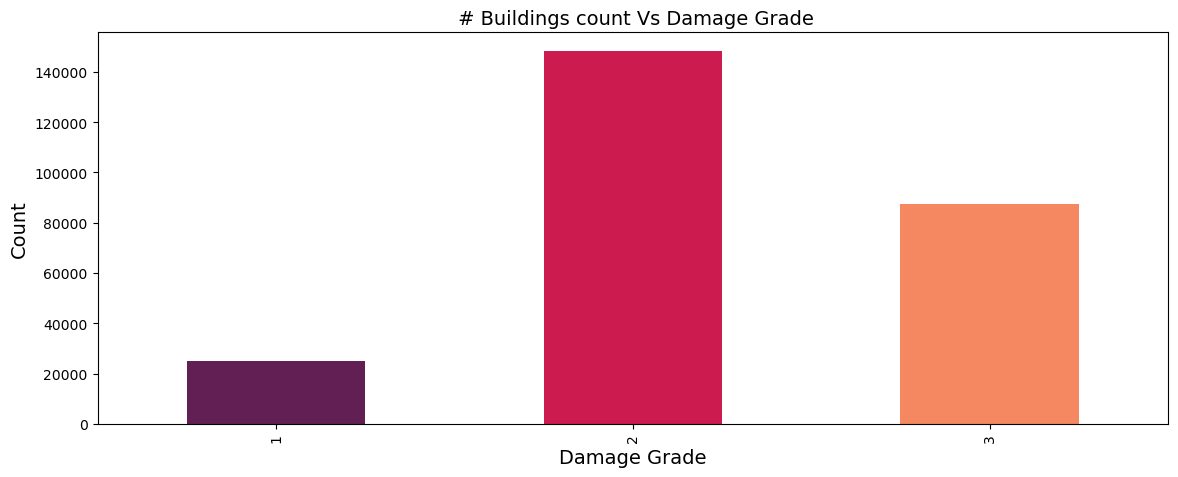

In [311]:
counts = train_labels.damage_grade.value_counts().sort_index()
colors = sns.color_palette("rocket", n_colors=len(counts))
ax = counts.plot.bar(figsize=(12,5), color=colors)
ax.set_title(" # Buildings count Vs Damage Grade")
ax.set_xlabel("Damage Grade")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

##### <span style="color:#0095b6"> Pr Notes Damage Grade Count + Mini visual Plot </span>

- <span style="color:#0095b6"> The data set shows imbalace related to Buildings count Vs Damage grade.</span>
- <span style="color:#0095b6"> Damage grade 2 accounts for more than 50 % of the total instances. </span>

#### <span style="color:#0095b6">  DataSet  Reduction &  Engineered Features </span>

1 - Data Set Reduced: Remove non relevant features following Structural principles for a building.
ie, legal ownership or secondary use is not relevant to evaluate a building structural or foundations capabilities.. Etc...

- Features to be removed :

   - ['legal_ownership_status'] , ['count_families'], ['has_secondary_use'],['has_secondary_use_agriculture '],['has_secondary_use_hotel']
   - ['has_secondary_use_rental'], ['has_secondary_use_institution'], ['has_secondary_use_school'], ['has_secondary_use_industry'],
   - ['has_secondary_use_health_post'],['has_secondary_use_gov_office'],['has_secondary_use_use_police'],['has_secondary_use_other']  

2 - Engineered Features: Extract create features to enhace performace
From features > count_floors_pre_eq , area_percentage  , height_percentage

- Engineered features :


  - A) New feature ['ratio_AxH'] = ['height_percentage'] / ['area_percentage']
  - B) New feature ['ratio_FxH'] = ['height_percentage'] / ['count_floors_pre_eq']

In [314]:
# Engineered new columns >  As float For precision

df_train['ratio_AxH'] = (df_train['height_percentage'] / df_train['area_percentage'])
df_train['ratio_FxH'] = (df_train['height_percentage'] / df_train['count_floors_pre_eq'])

In [324]:
# to reduced train
Xtr_sm = df_train[['geo_level_1_id','geo_level_2_id', 'geo_level_3_id']].copy() #, 'geo_level_2_id'
ytr_sm = df_train[['damage_grade']].copy()


##### Check data info on Xtr_sm + ytr_sm Set

In [327]:
Xtr_sm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   geo_level_1_id  260601 non-null  int64
 1   geo_level_2_id  260601 non-null  int64
 2   geo_level_3_id  260601 non-null  int64
dtypes: int64(3)
memory usage: 6.0 MB


#### <span style="color:#0095b6"> Split Dataset </span>

In [330]:
X_train, X_val, y_train, y_val = train_test_split(
    Xtr_sm,
    ytr_sm,
    test_size=0.2,
    random_state=42,
    stratify= ytr_sm
)

#### <span style="color:#0095b6"> Grid Search  for DTree classifier </span>

c. Use grid search with cross-validation (with the help of the `GridSearchCV` class) to find good hyperparameter values for a `DecisionTreeClassifier`. Hint: try various values for `max_leaf_nodes`.

In [334]:
from sklearn.model_selection import GridSearchCV
params = {
    #'max_leaf_nodes': list(range( 100, 200,500)),
    'max_depth': list(range(15, 21)),
    #'min_samples_split': [2, 3, 4]
}
grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42),
                              params,
                              cv=3)

grid_search_cv.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [15, 16, 17, 18, 19, 20]})

In [336]:
grid_search_cv.best_estimator_

DecisionTreeClassifier(max_depth=20, random_state=42)

### 17 Branches Train sm set +  predict sm set

In [339]:
# Train
tree_clf_sm = DecisionTreeClassifier(max_depth=20, random_state=42) # initialize
tree_clf_sm.fit(X_train, y_train)                                  # Fit

DecisionTreeClassifier(max_depth=20, random_state=42)

In [341]:
# Predict As is
tree_sm_preds = tree_clf_sm.predict(X_val) # Predict

#### Evaluation Confusion matrix and F1 Micro

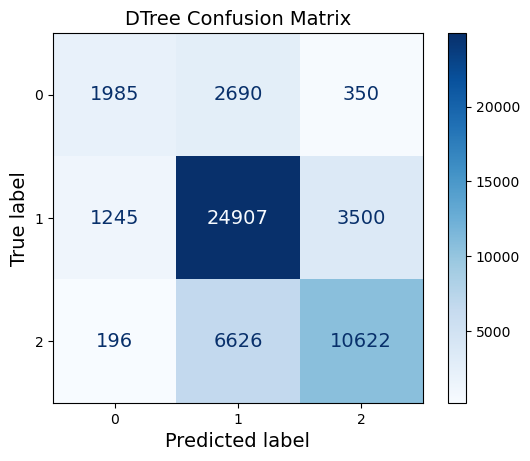

In [344]:
cm = confusion_matrix(y_val, tree_sm_preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("DTree Confusion Matrix")
plt.show()

In [346]:
rf_f1 = f1_score(y_val, tree_sm_preds, average='micro')
print("Decision tree with Validation F1:", rf_f1)

Decision tree with Validation F1: 0.7197482780453176


### PCA and rotation to see if F1 improve

In [351]:
pca_pipeline = make_pipeline(StandardScaler(), PCA())
X_train_rotated_array = pca_pipeline.fit_transform(X_train)

# Create column names for PCA components
n_components = X_train_rotated_array.shape[1]
pc_cols = [f"PC{i}" for i in range(n_components)]

# Wrap as DataFrame with names
X_train_rotated = pd.DataFrame(X_train_rotated_array, columns=pc_cols, index=X_train.index)

# Fit classifier with DataFrame (so it records feature names)
tree_clf_sm_pca = DecisionTreeClassifier(max_depth=20, random_state=42)
tree_clf_sm_pca.fit(X_train_rotated, y_train)

DecisionTreeClassifier(max_depth=20, random_state=42)

In [353]:
# Predict Pwith PCA and rotation to see if F1 improve

In [355]:
X_val_rotated = pca_pipeline.transform(X_val)
X_val_rotated = pd.DataFrame(X_val_rotated, columns=pc_cols, index=X_val.index)
tree_sm_preds_RT = tree_clf_sm_pca.predict(X_val_rotated)

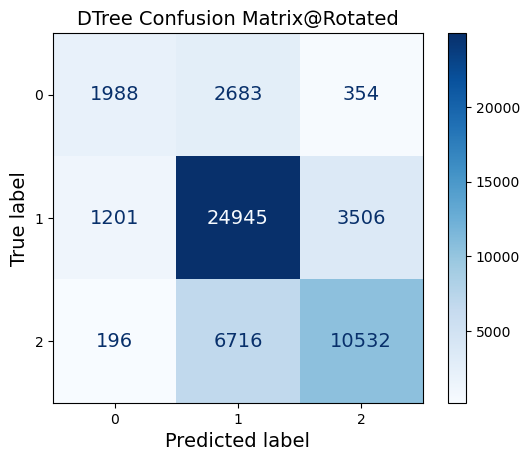

In [357]:
cmR = confusion_matrix(y_val, tree_sm_preds_RT)
ConfusionMatrixDisplay(confusion_matrix=cmR).plot(cmap='Blues')
plt.title("DTree Confusion Matrix@Rotated")
plt.show()

In [359]:
rf2_f1 = f1_score(y_val, tree_sm_preds_RT, average='micro')
print("Decision tree@ROT with Validation F1:", rf2_f1)

Decision tree@ROT with Validation F1: 0.7188081579401777
